In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

%matplotlib inline

In [52]:
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#3a3d4d',
    'axes.labelcolor':  '#e0e0e0',
    'xtick.color':      '#a0a0b0',
    'ytick.color':      '#a0a0b0',
    'text.color':       '#e0e0e0',
    'grid.color':       '#2a2d3d',
    'grid.alpha':       0.6,
    'legend.facecolor': '#1a1d27',
    'legend.edgecolor': '#3a3d4d',
    'font.family':      'DejaVu Sans',
})

In [53]:
sklearn_wine = load_wine()
wine_df = pd.DataFrame(sklearn_wine.data, columns=sklearn_wine.feature_names)
print(f'Liczba cech - {wine_df.shape[-1]}, liczba probek - {wine_df.shape[0]}; \nnazwy cech: \n{'\n'.join(wine_df.columns)}')

Liczba cech - 13, liczba probek - 178; 
nazwy cech: 
alcohol
malic_acid
ash
alcalinity_of_ash
magnesium
total_phenols
flavanoids
nonflavanoid_phenols
proanthocyanins
color_intensity
hue
od280/od315_of_diluted_wines
proline


In [75]:
wine_df['class'] = sklearn_wine.target
print(f'Rozklad klas \n {wine_df['class'].value_counts()}')


Rozklad klas 
 class
1    71
0    59
2    48
Name: count, dtype: int64


In [79]:
scaler = StandardScaler()
wine_scaled = scaler.fit_transform(wine_df.drop(columns='class'))
wine_scaled = pd.DataFrame(wine_scaled, columns=wine_df.drop(columns='class').columns)
wine_scaled['class'] = wine_df['class']
wine_scaled.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,class
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009,0
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242,0
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148,0
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574,0
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874,0


In [81]:
print("Standardyzacja konieczna przed PCA, bo PCA maksymalizuje wariancję.")
print("Cechy o większym zakresie wartości (np. Proline ~700)")
print("zdominowałyby wyniki bez normalizacji.")

Standardyzacja konieczna przed PCA, bo PCA maksymalizuje wariancję.
Cechy o większym zakresie wartości (np. Proline ~700)
zdominowałyby wyniki bez normalizacji.


In [80]:
print('Zadanie 2 PCA')

Zadanie 2 PCA


In [94]:
# 2. PCA calculation
features_only = wine_df.drop(columns='class')
scaler = StandardScaler()
wine_scaled_array = scaler.fit_transform(features_only)
wine_scaled = pd.DataFrame(wine_scaled_array, columns=features_only.columns)

pca = PCA()
X_pca_data = pca.fit_transform(wine_scaled)

eigenvalues = pca.explained_variance_
var_ratio = pca.explained_variance_ratio_ * 100
cumulative = np.cumsum(var_ratio)

print(f"\n{'PC':<6} {'Wartość własna':>16} {'% wariancji':>13} {'Skumulowana':>13}")
print("-" * 52)
for i, (ev, vr, cv) in enumerate(zip(eigenvalues, var_ratio, cumulative), 1):
    marker = " ←" if cv >= 80 and (i == 1 or cumulative[i-2] < 80) else ""
    print(f"PC{i:<4} {ev:>16.4f} {vr:>12.2f}% {cv:>12.2f}%{marker}")


PC       Wartość własna   % wariancji   Skumulowana
----------------------------------------------------
PC1              4.7324        36.20%        36.20%
PC2              2.5111        19.21%        55.41%
PC3              1.4542        11.12%        66.53%
PC4              0.9242         7.07%        73.60%
PC5              0.8580         6.56%        80.16% ←
PC6              0.6453         4.94%        85.10%
PC7              0.5541         4.24%        89.34%
PC8              0.3505         2.68%        92.02%
PC9              0.2905         2.22%        94.24%
PC10             0.2523         1.93%        96.17%
PC11             0.2271         1.74%        97.91%
PC12             0.1697         1.30%        99.20%
PC13             0.1040         0.80%       100.00%


In [84]:
print("3. Wizualizacja danych")

3. Wizualizacja danych


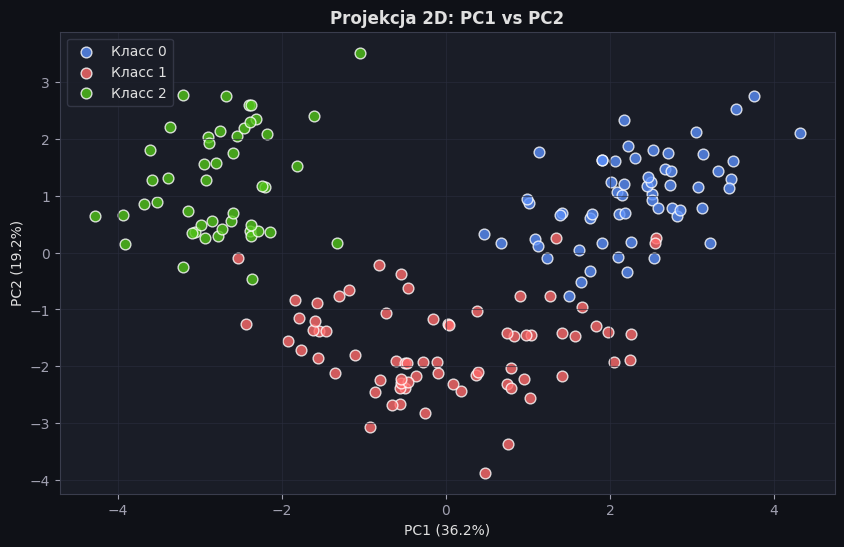

In [96]:
# 3.2 Projekcja 2D
plt.figure(figsize=(10, 6))
for cls, color, label in zip([0, 1, 2], COLORS, CLASS_LABELS):
    mask = y == cls
    plt.scatter(X_pca_data[mask, 0], X_pca_data[mask, 1],
                c=color, label=label, s=60, alpha=0.8, edgecolors='white')

plt.xlabel(f'PC1 ({var_ratio[0]:.1f}%)')
plt.ylabel(f'PC2 ({var_ratio[1]:.1f}%)')
plt.title('Projekcja 2D: PC1 vs PC2', fontweight='bold')
plt.legend()
plt.grid(True)
plt.show()

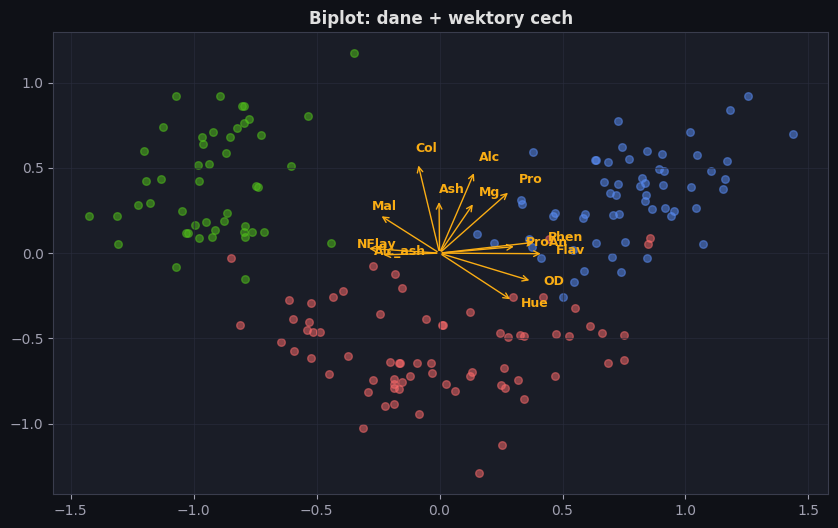

In [97]:
# 3.3 Biplot
plt.figure(figsize=(10, 6))
scale = 3.0
for cls, color, label in zip([0, 1, 2], COLORS, CLASS_LABELS):
    mask = y == cls
    plt.scatter(X_pca_data[mask, 0] / scale, X_pca_data[mask, 1] / scale,
                c=color, label=label, s=30, alpha=0.5)

loadings = pca.components_.T
feature_short = ['Alc', 'Mal', 'Ash', 'Alc_ash', 'Mg', 'Phen', 'Flav', 'NFlav', 'ProAn', 'Col', 'Hue', 'OD', 'Pro']

for i, (fx, fy, name) in enumerate(zip(loadings[:, 0], loadings[:, 1], feature_short)):
    plt.annotate('', xy=(fx, fy), xytext=(0, 0), arrowprops=dict(arrowstyle='->', color='#faad14'))
    plt.text(fx * 1.12, fy * 1.12, name, color='#faad14', fontsize=9, fontweight='bold')

plt.title('Biplot: dane + wektory cech', fontweight='bold')
plt.grid(True)
plt.show()

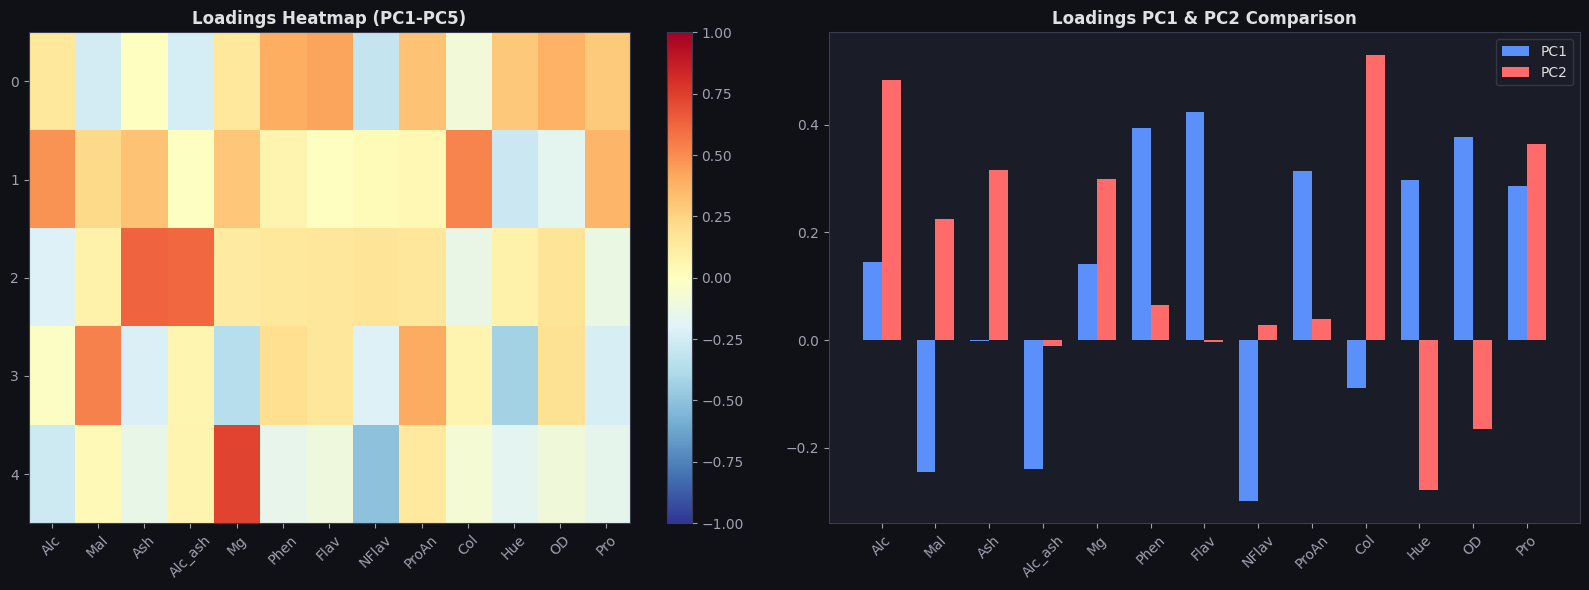

In [98]:
# 3.4 Loadings Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
loadings_df = pd.DataFrame(pca.components_[:5, :], columns=feature_short)
im = ax1.imshow(loadings_df.values, cmap='RdYlBu_r', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax1)
ax1.set_title('Loadings Heatmap (PC1-PC5)', fontweight='bold')
ax1.set_xticks(range(len(feature_short)))
ax1.set_xticklabels(feature_short, rotation=45)

# Bar chart for PC1 & PC2
x_idx = np.arange(len(feature_short))
w = 0.35
ax2.bar(x_idx - w/2, pca.components_[0], w, label='PC1', color='#5b8ff9')
ax2.bar(x_idx + w/2, pca.components_[1], w, label='PC2', color='#ff6b6b')
ax2.set_xticks(x_idx)
ax2.set_xticklabels(feature_short, rotation=45)
ax2.set_title('Loadings PC1 & PC2 Comparison', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

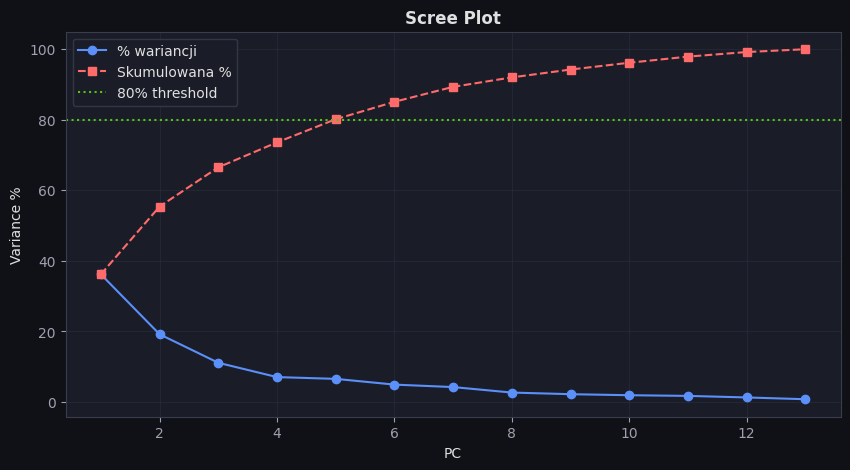

In [95]:
# 3.1 Scree Plot
y = wine_df['class'].values
COLORS = ['#5b8ff9', '#ff6b6b', '#52c41a']
CLASS_LABELS = ['Класс 0', 'Класс 1', 'Класс 2']

plt.figure(figsize=(10, 5))
xs = np.arange(1, len(var_ratio) + 1)
plt.plot(xs, var_ratio, 'o-', label='% wariancji', color='#5b8ff9')
plt.plot(xs, cumulative, 's--', label='Skumulowana %', color='#ff6b6b')
plt.axhline(80, color='#52c41a', ls=':', label='80% threshold')
plt.title('Scree Plot', fontweight='bold')
plt.xlabel('PC')
plt.ylabel('Variance %')
plt.legend()
plt.grid(True)
plt.show()

4.
Które cechy dominują w PC1?
W PC1 dominują cechy związane z polifenolami: flavanoids (+0.42), total_phenols (+0.39), od280/od315 (+0.38), proanthocyanins (+0.31). Ujemnie załadowane są nonflavanoid_phenols (-0.30) i alcalinity_of_ash (-0.24).
Co reprezentuje PC1?
PC1 reprezentuje "jakość polifenolową" wina — gradient od win bogatych w flawonoidy i fenole (klasa 0) do win ubogich w te związki (klasa 2). Wyjaśnia 36.2% całkowitej wariancji.
Które cechy dominują w PC2?
W PC2 dominują: color_intensity (+0.53), alcohol (+0.48), proline (+0.36), ash (+0.32). PC2 reprezentuje "intensywność i moc" wina — ciemne, mocne wina z wysoką zawartością proliny.
Czy klasy są dobrze separowalne w 2D?
Tak. Na wykresie PC1 vs PC2 trzy klasy tworzą wyraźnie oddzielone skupiska. Klasa 0 skupia się po prawej stronie (wysokie PC1), klasa 2 po lewej (niskie PC1), klasa 1 w centrum. Dwa pierwsze komponenty wyjaśniają łącznie 55.4% wariancji, co wystarcza do skutecznej separacji wizualnej.
Która cecha zdominowała analizę bez standaryzacji?
Bez standaryzacji PC1 wyjaśniałby aż 99.8% wariancji, a dominującą cechą byłaby proline — jej zakres wartości wynosi 278–1680 mg/l, podczas gdy np. ash ma zakres zaledwie 1.4–3.2. PCA bez skalowania "widzi" tylko różnice w jednostkach miary, nie w strukturze danych.